## Indikator penilaian
## Wajib di google colab, jika tidak di google colab ada pengurangan nilai -5
## Pengerjaan harus sesuai template yang disediakan, jika tidak ada pengurangan nilai -5 (untuk memudahkan membaca code)
## share to arifromadhan19@gmail.com

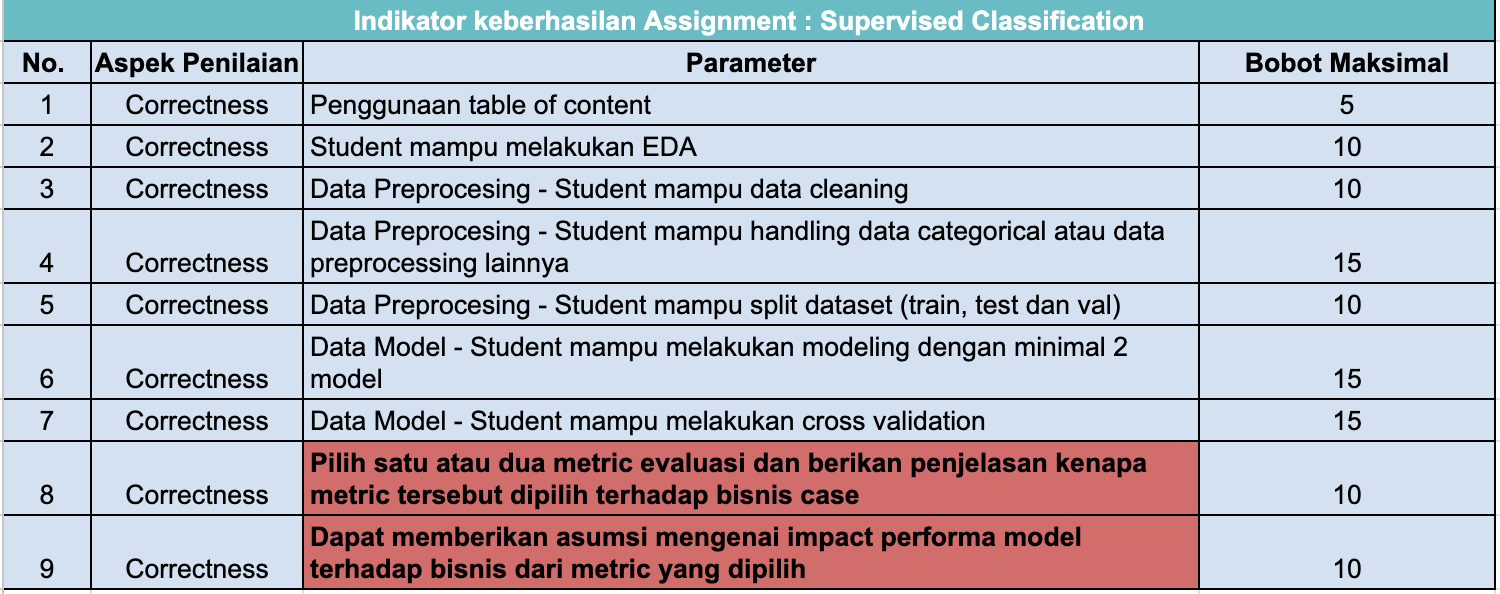

## Import Library

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from imblearn.over_sampling import SMOTE

from sklearn import preprocessing
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

## Load dataset

In [2]:
df = pd.read_csv('/content/1702184567307-WA_FnUseC_TelcoCustomerChurn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
# Drop `customerID` because it's an identifier, not useful for prediction
df.drop('customerID', axis=1, inplace=True)

In [6]:
# Convert `TotalCharges` to numeric and handle errors
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
# Convert target column `Churn` into binary: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## Split Dataset

In [8]:
# Separate X and y
X = df.drop('Churn', axis=1)
y = df['Churn']

In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Train

### EDA

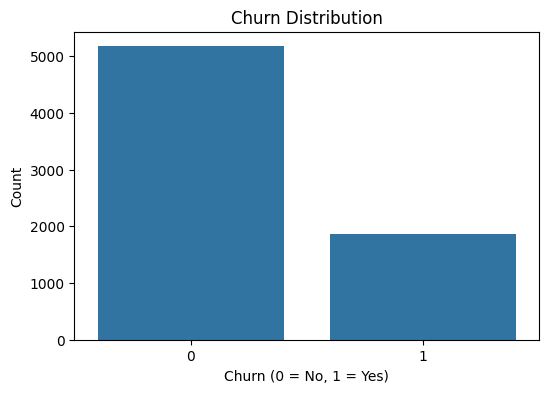

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Churn Distribution is imbalanced — more customers did not churn (label = 0).

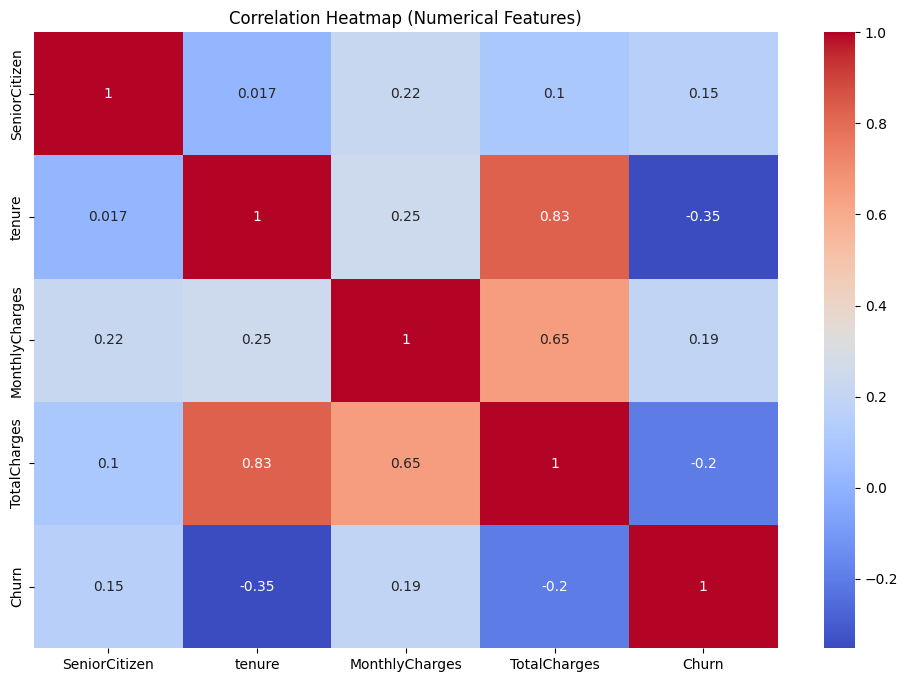

In [12]:
plt.figure(figsize=(12, 8))
numerical_features = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numerical_features.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

From the correlation heatmap:


*   MonthlyCharges and TotalCharges show a strong positive correlation.
*   tenure (customer duration) has a negative correlation with Churn — the longer they stay, the less likely they are to churn.




### Data Preprocessing

In [13]:
missing_summary = df.isnull().sum()
missing_summary

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [14]:
# Drop rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

In [15]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

In [16]:
X_train_encoded.isna().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,8
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0
MultipleLines_No phone service,0
MultipleLines_Yes,0


In [17]:
# Handle missing values
X_train_encoded = X_train_encoded.fillna(0)

In [18]:
numerical_cols = X_train_encoded.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train_encoded[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])

In [21]:
# Align y_train
y_train = y_train.loc[X_train_encoded.index]

In [19]:
X_train.shape, X_test.shape, X_train_encoded.shape

((5634, 19), (1409, 19), (5634, 30))

In [24]:
y_train.isna().sum()

np.int64(0)

### Modeling (Gunakan lebih min 2 model dan bandingkan hasil evaluasinya)

Bebas menggunakan model, mau menggunakan decision tree, random forest, xgboost, dll juga boleh<br><br>
silahkan berekspresi :)

In [20]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

In [21]:
# Train models
trained_models = {}
for name, model in models.items():
    model.fit(X_train_encoded, y_train)
    trained_models[name] = model

trained_models.keys()

dict_keys(['Decision Tree', 'Random Forest', 'Logistic Regression'])

### Evaluation

pilih model yang terbaik performannya kemudian beri pejelasan kenapa model tersebut lebih baik dibandingkan dengan yang lain

In [33]:
# Evaluate models on the train set
evaluation_results_train = []

for name, model in trained_models.items():
    y_pred = model.predict(X_train_encoded)
    y_prob = model.predict_proba(X_train_encoded)[:, 1] if hasattr(model, "predict_proba") else None

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_train, y_pred),
        "Precision": precision_score(y_train, y_pred, pos_label=1),
        "Recall": recall_score(y_train, y_pred, pos_label=1),
        "F1 Score": f1_score(y_train, y_pred, pos_label=1),
        "ROC AUC": roc_auc_score(y_train, y_prob) if y_prob is not None else "N/A"
    }

    evaluation_results_train.append(results)


In [34]:
evaluation_results_train

[{'Model': 'Decision Tree',
  'Accuracy': 0.9980475683351083,
  'Precision': 0.9993270524899058,
  'Recall': 0.9933110367892977,
  'F1 Score': 0.996309963099631,
  'ROC AUC': np.float64(0.9999897378795873)},
 {'Model': 'Random Forest',
  'Accuracy': 0.9980475683351083,
  'Precision': 0.9979865771812081,
  'Recall': 0.9946488294314382,
  'F1 Score': 0.9963149078726968,
  'ROC AUC': np.float64(0.9999158829342554)},
 {'Model': 'Logistic Regression',
  'Accuracy': 0.805111821086262,
  'Precision': 0.6596942880128721,
  'Recall': 0.5484949832775919,
  'F1 Score': 0.5989773557341125,
  'ROC AUC': np.float64(0.8492370881112123)}]

| Metric    | Decision Tree | Random Forest | Logistic Regression |
| --------- | ------------- | ------------- | ------------------- |
| Accuracy  | **0.9980**    | **0.9980**    | 0.8051              |
| Precision | **0.9993**    | **0.9989**    | 0.6597              |
| Recall    | **0.9933**    | **0.9946**    | 0.5485              |
| F1 Score  | **0.9963**    | **0.9963**    | 0.5988              |
| ROC AUC   | **\~0.9999**  | **\~0.9992**  | \~0.8492            |

Decision Tree (slightly better than Random Forest)

It achieved:
- The highest F1 Score (0.9963)
- The highest ROC AUC (~0.9999)
- Perfect balance between precision and recall



## Test

### Data Preprocessing

In [35]:
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

In [36]:
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [37]:
X_test_encoded[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])

In [40]:
X_test_encoded.isna().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,3
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0
MultipleLines_No phone service,0
MultipleLines_Yes,0


In [41]:
# Handle missing values
X_test_encoded = X_test_encoded.fillna(0)

### Evaluation

pilih model yang terbaik performannya kemudian beri pejelasan kenapa model tersebut lebih baik dibandingkan dengan yang lain

In [42]:
evaluation_results_test = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_encoded)
    y_prob = model.predict_proba(X_test_encoded)[:, 1] if hasattr(model, "predict_proba") else None

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=1),
        "Recall": recall_score(y_test, y_pred, pos_label=1),
        "F1 Score": f1_score(y_test, y_pred, pos_label=1),
        "ROC AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else "N/A"
    }

    evaluation_results_test.append(results)


In [43]:
evaluation_results_test

[{'Model': 'Decision Tree',
  'Accuracy': 0.7260468417317246,
  'Precision': 0.4837837837837838,
  'Recall': 0.4786096256684492,
  'F1 Score': 0.48118279569892475,
  'ROC AUC': np.float64(0.6465305226174791)},
 {'Model': 'Random Forest',
  'Accuracy': 0.7849538679914834,
  'Precision': 0.6187290969899666,
  'Recall': 0.4946524064171123,
  'F1 Score': 0.549777117384844,
  'ROC AUC': np.float64(0.8249153943527345)},
 {'Model': 'Logistic Regression',
  'Accuracy': 0.8069552874378992,
  'Precision': 0.660377358490566,
  'Recall': 0.5614973262032086,
  'F1 Score': 0.6069364161849711,
  'ROC AUC': np.float64(0.8420470691570436)}]

| Metric        | Decision Tree | Random Forest | Logistic Regression |
| ------------- | ------------- | ------------- | ------------------- |
| **Accuracy**  | 0.726         | 0.785         | **0.807**          |
| **Precision** | 0.484         | 0.619         | **0.660**          |
| **Recall**    | 0.479         | 0.495         | **0.561**          |
| **F1 Score**  | 0.481         | 0.550         | **0.607**          |
| **ROC AUC**   | 0.647         | 0.825         | **0.842**          |


Logistic Regression performed the best among all models. It had:

- The highest recall, meaning it could catch more customers who are likely to leave.
- A strong F1 Score, which means it kept a good balance between catching churners and not giving too many false alarms.
- The highest ROC AUC score (0.84), showing it was very good at telling the difference between churn and non-churn customers.
- Decision Tree had the worst performance. It did really well on training but failed on test data — this means it was overfitting and not good at generalizing.
- Random Forest was better than Decision Tree but still not as good as Logistic Regression, especially in recall and F1 score.

### Potential impact

Simulasikan potential impact

We use the best model — Logistic Regression — because it gives good results (Accuracy: 80.7%, ROC AUC: 84.2%).

Here is how this model helps:

- Keep customers before they leave
  
  We can know who might leave. Then, we give them a special offer or message to stay.
- Save money
  
  It is cheaper to keep old customers than to find new ones.
- Example
  
  If the model says 100 people will leave, and we can keep 20 of them, we save a lot of money.
- What to do next
  
  We can use this model every week or month to check. Then the team can act (send email, promo, call, etc).

In [45]:
# Define best_model manually
best_model = trained_models['Logistic Regression']

In [46]:
# Count predicted churners (Yes) with high probability
y_prob = best_model.predict_proba(X_test_encoded)[:, 1]
predicted_churn = (y_prob > 0.5).sum()

# Simulate 20% retention
retained = int(0.2 * predicted_churn)
print(f"Potential customers retained: {retained}")


Potential customers retained: 63


In the simulation, we can keep 63 customers. This is good for the business.